# Linear Downsample Cross-Subject Summary

This notebook aggregates all `linear_downsample_cross` results from `result_5/linear_downsample`.

It intentionally does **not** save figures or tables by default. The outputs are displayed inside the notebook only.

Main behavior:
- read `leaderboard_test.json` from each dataset / seed / model result
- aggregate `test_accuracy` across seeds
- show mean accuracy in the heatmap cells
- mark missing results as `×`
- gray out results that are not significantly above chance when a statistical test is available

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

try:
    from scipy.stats import binomtest, ttest_1samp
except Exception:
    binomtest = None
    ttest_1samp = None

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

In [2]:
# -----------------------
# Config
# -----------------------
REPO_ROOT = Path("/benchmark-eeg/5.0_version")
RESULT_ROOT = REPO_ROOT / "result_5" / "linear_downsample"
REFERENCE_CSV = REPO_ROOT / "experiment_tracking" / "experiment_reference.csv"

MODE = "cross_subject"
SEEDS = [42, 10, 5]
MODEL_ORDER = ["brainomni", "labram", "biot", "femba", "neurolm", "cbramod", "neurogpt", "reve", "eegmamba", "bendr"]

ALPHA = 0.05
DISPLAY_AS_PERCENT = True
COLOR_BY = "normalized_gain"  # "accuracy" or "normalized_gain"
INCLUDE_PARTIAL = True

CATEGORY_COLORS = {
    "Type-I": "#E58AD9",
    "Type-II": "#B58BFF",
    "Type-III": "#5FA2F1",
    "Type-IV": "#62C5AE",
    "Type-V": "#FFA06A",
    "Type-VI": "#EF5A83",
    "Type-VII": "#B978D6",
    "": "#BBBBBB",
}

print("RESULT_ROOT:", RESULT_ROOT)
print("REFERENCE_CSV:", REFERENCE_CSV)

RESULT_ROOT: /benchmark-eeg/5.0_version/result_5/linear_downsample
REFERENCE_CSV: /benchmark-eeg/5.0_version/experiment_tracking/experiment_reference.csv


In [3]:
# -----------------------
# Name normalization / fuzzy matching
# -----------------------
def clean(value):
    return "" if value is None or (isinstance(value, float) and np.isnan(value)) else str(value).strip()


def normalize_name(value: str) -> str:
    key = clean(value).lower()
    replacements = {
        "–": "_",
        "—": "_",
        "-": "_",
        " ": "_",
        "（": "(",
        "）": ")",
        "monitering": "monitoring",
        "extraversial": "extraversion",
        "fintuen": "finetune",
    }
    for src, dst in replacements.items():
        key = key.replace(src, dst)
    key = re.sub(r"\([^)]*\)", "", key)
    key = re.sub(r"_balanced$", "", key)
    key = re.sub(r"_old_badscale$", "", key)
    key = re.sub(r"_wsn$", "", key)
    return re.sub(r"[^a-z0-9]+", "", key)


def names_match(query: str, candidate: str) -> bool:
    q = normalize_name(query)
    c = normalize_name(candidate)
    if not q or not c:
        return False
    return q == c or (len(q) >= 5 and q in c) or (len(c) >= 5 and c in q)


def parse_chance(text) -> float | None:
    text = clean(text)
    if "/" not in text:
        return None
    right = text.split("/")[-1].strip()
    m = re.search(r"([0-9]*\.?[0-9]+)", right)
    return float(m.group(1)) if m else None


def result_dataset_from_dir(name: str, mode: str = MODE) -> str:
    marker = f"_{mode}_"
    return name.split(marker, 1)[0] if marker in name else name

In [4]:
# -----------------------
# Load reference table
# -----------------------
ref = pd.read_csv(REFERENCE_CSV)
ref = ref.copy()
ref["dataset_display"] = ref["dataset"].astype(str)
ref["dataset_key"] = ref["dataset_display"].map(normalize_name)
ref["chance"] = ref["bacc_chance"].map(parse_chance)

# Empty cell means this experiment is applicable; N/A means skip.
applicable = ref[ref["linear_downsample_cross"].fillna("").str.upper() != "N/A"].copy()
print("Reference rows:", len(ref))
print("Applicable linear_downsample_cross rows:", len(applicable))
applicable[["category", "dataset_display", "bacc_chance", "chance", "linear_downsample_cross"]].head(20)

Reference rows: 57
Applicable linear_downsample_cross rows: 57


,category,dataset_display,bacc_chance,chance,linear_downsample_cross
0,Type-I,EEG_IO,— / 0.500,0.500,NaN
1,Type-I,Longitudinal_EEG_Reliability,0.8161 / 0.500,0.500,NaN
2,Type-I,HFO,0.7439 / 0.500,0.500,NaN
3,Type-II,LEMON_age,0.3429 / 0.333,0.333,NaN
4,Type-II,LEMON_gender,0.7340 / 0.500,0.500,NaN
5,Type-II,LEMON_extraversial,0.6450 / 0.500,0.500,NaN
6,Type-II,ADHD,0.5331 / 0.500,0.500,NaN
7,Type-II,AD65,0.6128 / 0.333,0.333,NaN
8,Type-II,PD31,0.5263 / 0.500,0.500,NaN
9,Type-II,EEG_Mortality_PD,0.7580 / 0.500,0.500,NaN


In [5]:
# -----------------------
# Discover result directories
# -----------------------
result_dirs = []
if RESULT_ROOT.exists():
    for path in RESULT_ROOT.iterdir():
        if not path.is_dir():
            continue
        if f"_{MODE}_" not in path.name:
            continue
        result_dirs.append(path)

result_dir_df = pd.DataFrame({
    "result_dir": result_dirs,
    "result_dir_name": [p.name for p in result_dirs],
    "result_dataset": [result_dataset_from_dir(p.name) for p in result_dirs],
})
result_dir_df["result_key"] = result_dir_df["result_dataset"].map(normalize_name)
print("Discovered result dirs:", len(result_dir_df))
result_dir_df.head()

Discovered result dirs: 57


,result_dir,result_dir_name,result_dataset,result_key
0,/benchmark-eeg/5.0_version/result_5/linear_dow...,AD65_cross_subject_linear_downsample,AD65,ad65
1,/benchmark-eeg/5.0_version/result_5/linear_dow...,ADHD_cross_subject_linear_downsample,ADHD,adhd
2,/benchmark-eeg/5.0_version/result_5/linear_dow...,ADHD_wsn_cross_subject_linear_downsample,ADHD_wsn,adhd
3,/benchmark-eeg/5.0_version/result_5/linear_dow...,Awakening_balanced_cross_subject_linear_downsa...,Awakening_balanced,awakening
4,/benchmark-eeg/5.0_version/result_5/linear_dow...,Awakening_balanced_cross_subject_linear_prob,Awakening_balanced,awakening


In [6]:
# -----------------------
# Match reference datasets to result directories
# -----------------------
def choose_result_dir(dataset_display: str) -> Path | None:
    if result_dir_df.empty:
        return None
    exact = result_dir_df[result_dir_df["result_key"] == normalize_name(dataset_display)]
    if len(exact):
        return exact.iloc[0]["result_dir"]
    fuzzy = result_dir_df[result_dir_df["result_dataset"].map(lambda x: names_match(dataset_display, x))]
    if len(fuzzy):
        # Prefer linear_downsample suffix, then shortest name.
        tmp = fuzzy.copy()
        tmp["score"] = tmp["result_dir_name"].map(lambda x: (0 if x.endswith("linear_downsample") else 1, len(x), x))
        return tmp.sort_values("score").iloc[0]["result_dir"]
    return None

matched = applicable.copy()
matched["result_dir"] = matched["dataset_display"].map(choose_result_dir)
matched["result_dir_name"] = matched["result_dir"].map(lambda p: p.name if isinstance(p, Path) else "")
print("Matched:", matched["result_dir"].notna().sum(), "/", len(matched))
matched.loc[matched["result_dir"].isna(), ["category", "dataset_display", "linear_downsample_cross"]].head(50)

Matched: 51 / 57


,category,dataset_display,linear_downsample_cross
0,Type-I,EEG_IO,NaN
14,Type-II,TUEP,NaN
16,Type-III,ISRUC_S1,NaN
19,Type-III,SleepEDF_full,NaN
46,Type-VII,CHB_MIT,NaN
52,Type-VII,Workload,NaN


In [7]:
# -----------------------
# Read leaderboard_test.json files
# -----------------------
records = []
for _, row in matched.iterrows():
    result_dir = row["result_dir"]
    if not isinstance(result_dir, Path):
        continue
    for seed in SEEDS:
        leaderboard = result_dir / f"seed_{seed}_downsample_t40" / "ratio_full" / "leaderboard_test.json"
        if not leaderboard.exists():
            continue
        try:
            data = json.loads(leaderboard.read_text())
        except Exception as exc:
            print("Failed to read", leaderboard, exc)
            continue
        for item in data:
            model = clean(item.get("model")).lower()
            if model not in MODEL_ORDER:
                continue
            acc = item.get("test_accuracy")
            if acc is None:
                continue
            records.append({
                "category": row["category"],
                "dataset_display": row["dataset_display"],
                "dataset_key": row["dataset_key"],
                "result_dir_name": result_dir.name,
                "seed": seed,
                "model": model,
                "test_accuracy": float(acc),
                "chance": row["chance"],
                "leaderboard_path": str(leaderboard),
            })

long_df = pd.DataFrame(records)
print("Rows:", len(long_df))
print("Datasets with results:", long_df["dataset_display"].nunique() if len(long_df) else 0)
long_df.head()

Rows: 1296
Datasets with results: 45


,category,dataset_display,dataset_key,result_dir_name,seed,model,test_accuracy,chance,leaderboard_path
0,Type-I,Longitudinal_EEG_Reliability,longitudinaleegreliability,Longitudinal_EEG_Reliability_wsn_cross_subject...,42,brainomni,0.739414,0.5,/benchmark-eeg/5.0_version/result_5/linear_dow...
1,Type-I,Longitudinal_EEG_Reliability,longitudinaleegreliability,Longitudinal_EEG_Reliability_wsn_cross_subject...,42,biot,0.738421,0.5,/benchmark-eeg/5.0_version/result_5/linear_dow...
2,Type-I,Longitudinal_EEG_Reliability,longitudinaleegreliability,Longitudinal_EEG_Reliability_wsn_cross_subject...,42,neurolm,0.730615,0.5,/benchmark-eeg/5.0_version/result_5/linear_dow...
3,Type-I,Longitudinal_EEG_Reliability,longitudinaleegreliability,Longitudinal_EEG_Reliability_wsn_cross_subject...,42,femba,0.719719,0.5,/benchmark-eeg/5.0_version/result_5/linear_dow...
4,Type-I,Longitudinal_EEG_Reliability,longitudinaleegreliability,Longitudinal_EEG_Reliability_wsn_cross_subject...,42,labram,0.686192,0.5,/benchmark-eeg/5.0_version/result_5/linear_dow...


In [8]:
# -----------------------
# Estimate test-set size where possible
# -----------------------
def read_manifest_test_n(result_dir: Path, seed: int) -> int | None:
    # Typical split manifests live under indices/<dataset>_indices_cross_subject/seed_*_downsample_t40/split_manifest.json.
    candidates = [
        REPO_ROOT / "indices" / f"{result_dataset_from_dir(result_dir.name)}_indices_cross_subject" / f"seed_{seed}_downsample_t40" / "split_manifest.json",
        REPO_ROOT / "indices" / f"{result_dataset_from_dir(result_dir.name)}_indices_cross_subject" / f"seed_{seed}" / "split_manifest.json",
    ]
    for path in candidates:
        if not path.exists():
            continue
        try:
            m = json.loads(path.read_text())
        except Exception:
            continue
        if "counts" in m and "test" in m["counts"] and "samples" in m["counts"]["test"]:
            return int(m["counts"]["test"]["samples"])
        if "splits" in m and "test" in m["splits"]:
            return len(m["splits"]["test"])
    return None

manifest_records = []
for _, row in matched.dropna(subset=["result_dir"]).iterrows():
    result_dir = row["result_dir"]
    for seed in SEEDS:
        manifest_records.append({
            "dataset_display": row["dataset_display"],
            "seed": seed,
            "n_test": read_manifest_test_n(result_dir, seed),
        })
manifest_df = pd.DataFrame(manifest_records)
manifest_df.head()

,dataset_display,seed,n_test
0,Longitudinal_EEG_Reliability,42,4970.0
1,Longitudinal_EEG_Reliability,10,4970.0
2,Longitudinal_EEG_Reliability,5,4970.0
3,HFO,42,2752.0
4,HFO,10,7724.0


In [9]:
# -----------------------
# Aggregate seed results and significance
# -----------------------
def one_sided_binom_p(mean_acc, chance, n_test):
    if binomtest is None or pd.isna(mean_acc) or pd.isna(chance) or pd.isna(n_test) or n_test <= 0:
        return None
    k = int(round(float(mean_acc) * int(n_test)))
    k = min(max(k, 0), int(n_test))
    return float(binomtest(k, int(n_test), p=float(chance), alternative="greater").pvalue)


def one_sided_t_p(values, chance):
    values = [float(x) for x in values if not pd.isna(x)]
    if ttest_1samp is None or len(values) < 2 or pd.isna(chance):
        return None
    res = ttest_1samp(values, popmean=float(chance), alternative="greater")
    return float(res.pvalue) if not pd.isna(res.pvalue) else None

summary_rows = []
for (dataset, model), part in long_df.groupby(["dataset_display", "model"], sort=False):
    accs = part["test_accuracy"].astype(float).tolist()
    chance = part["chance"].dropna().iloc[0] if part["chance"].notna().any() else np.nan
    n_tests = manifest_df.loc[manifest_df["dataset_display"] == dataset, "n_test"].dropna().astype(int).tolist()
    n_test = int(round(np.mean(n_tests))) if n_tests else np.nan
    mean_acc = float(np.mean(accs))
    p_binom = one_sided_binom_p(mean_acc, chance, n_test) if not pd.isna(n_test) else None
    p_t = one_sided_t_p(accs, chance)
    p_value = p_binom if p_binom is not None else p_t
    test_method = "binomial" if p_binom is not None else ("seed_ttest" if p_t is not None else "mean_vs_chance")
    significant = (p_value < ALPHA) if p_value is not None else (mean_acc > chance if not pd.isna(chance) else None)
    summary_rows.append({
        "dataset_display": dataset,
        "category": part["category"].iloc[0],
        "model": model,
        "mean_accuracy": mean_acc,
        "std_accuracy": float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan,
        "n_seed": len(accs),
        "missing_seeds": ",".join(str(s) for s in SEEDS if s not in set(part["seed"].astype(int))),
        "chance": chance,
        "n_test": n_test,
        "p_value": p_value,
        "test_method": test_method,
        "significant": significant,
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.shape)
summary_df.head(20)

/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/s

/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/s

(450, 12)


/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,dataset_display,category,model,mean_accuracy,std_accuracy,n_seed,missing_seeds,chance,n_test,p_value,test_method,significant
0,Longitudinal_EEG_Reliability,Type-I,brainomni,0.739525,0.009698,3,,0.5,4970,2.295424e-260,binomial,True
1,Longitudinal_EEG_Reliability,Type-I,biot,0.724853,0.012593,3,,0.5,4970,6.684608e-229,binomial,True
2,Longitudinal_EEG_Reliability,Type-I,neurolm,0.737046,0.008612,3,,0.5,4970,5.831857e-255,binomial,True
3,Longitudinal_EEG_Reliability,Type-I,femba,0.723191,0.008208,3,,0.5,4970,3.953212e-225,binomial,True
4,Longitudinal_EEG_Reliability,Type-I,labram,0.692239,0.005410,3,,0.5,4970,5.981919e-166,binomial,True
5,Longitudinal_EEG_Reliability,Type-I,eegmamba,0.677246,0.005130,3,,0.5,4970,5.270337e-141,binomial,True
6,Longitudinal_EEG_Reliability,Type-I,neurogpt,0.653196,0.005184,3,,0.5,4970,3.532361e-105,binomial,True
7,Longitudinal_EEG_Reliability,Type-I,cbramod,0.648166,0.015714,3,,0.5,4970,2.031101e-98,binomial,True
8,Longitudinal_EEG_Reliability,Type-I,reve,0.637844,0.005271,3,,0.5,4970,2.281459e-85,binomial,True
9,Longitudinal_EEG_Reliability,Type-I,bendr,0.499168,0.002656,3,,0.5,4970,5.507912e-01,binomial,False


In [10]:
# -----------------------
# Pivot tables for plotting
# -----------------------
# Keep the reference order, but only datasets that have at least one result unless INCLUDE_PARTIAL=False behavior changes later.
dataset_order = [d for d in matched["dataset_display"].tolist() if d in set(summary_df["dataset_display"])]
category_by_dataset = matched.set_index("dataset_display")["category"].to_dict()
chance_by_dataset = matched.set_index("dataset_display")["chance"].to_dict()

acc_pivot = summary_df.pivot(index="dataset_display", columns="model", values="mean_accuracy").reindex(index=dataset_order, columns=MODEL_ORDER)
sig_pivot = summary_df.pivot(index="dataset_display", columns="model", values="significant").reindex(index=dataset_order, columns=MODEL_ORDER)
seed_pivot = summary_df.pivot(index="dataset_display", columns="model", values="n_seed").reindex(index=dataset_order, columns=MODEL_ORDER)
chance_series = pd.Series(chance_by_dataset).reindex(dataset_order).astype(float)

if COLOR_BY == "normalized_gain":
    color_matrix = acc_pivot.sub(chance_series, axis=0).div(1 - chance_series, axis=0)
    color_label = "Normalized gain over chance"
else:
    color_matrix = acc_pivot.copy()
    color_label = "Test accuracy"

model_mean_acc = acc_pivot.mean(axis=0, skipna=True)
model_avg_rank = acc_pivot.rank(axis=1, ascending=False, method="average").mean(axis=0, skipna=True)

acc_pivot.head()

model,brainomni,labram,biot,femba,neurolm,cbramod,neurogpt,reve,eegmamba,bendr
dataset_display,,,,,,,,,,
Longitudinal_EEG_Reliability,0.739525,0.692239,0.724853,0.723191,0.737046,0.648166,0.653196,0.637844,0.677246,0.499168
HFO,0.556457,0.535070,0.580607,0.523403,0.543069,0.576679,0.542483,0.507951,0.577184,0.504448
LEMON_age,0.455255,0.437587,0.485710,0.482434,0.388561,0.333333,0.430755,0.439047,0.331510,0.333347
LEMON_gender,0.537526,0.577873,0.580265,0.553535,0.581697,0.505108,0.532732,0.537210,0.498984,0.499831
LEMON_extraversial,0.474916,0.501633,0.497808,0.519238,0.508771,0.527344,0.477895,0.503938,0.506266,0.503245


/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/eeg-bench-new/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


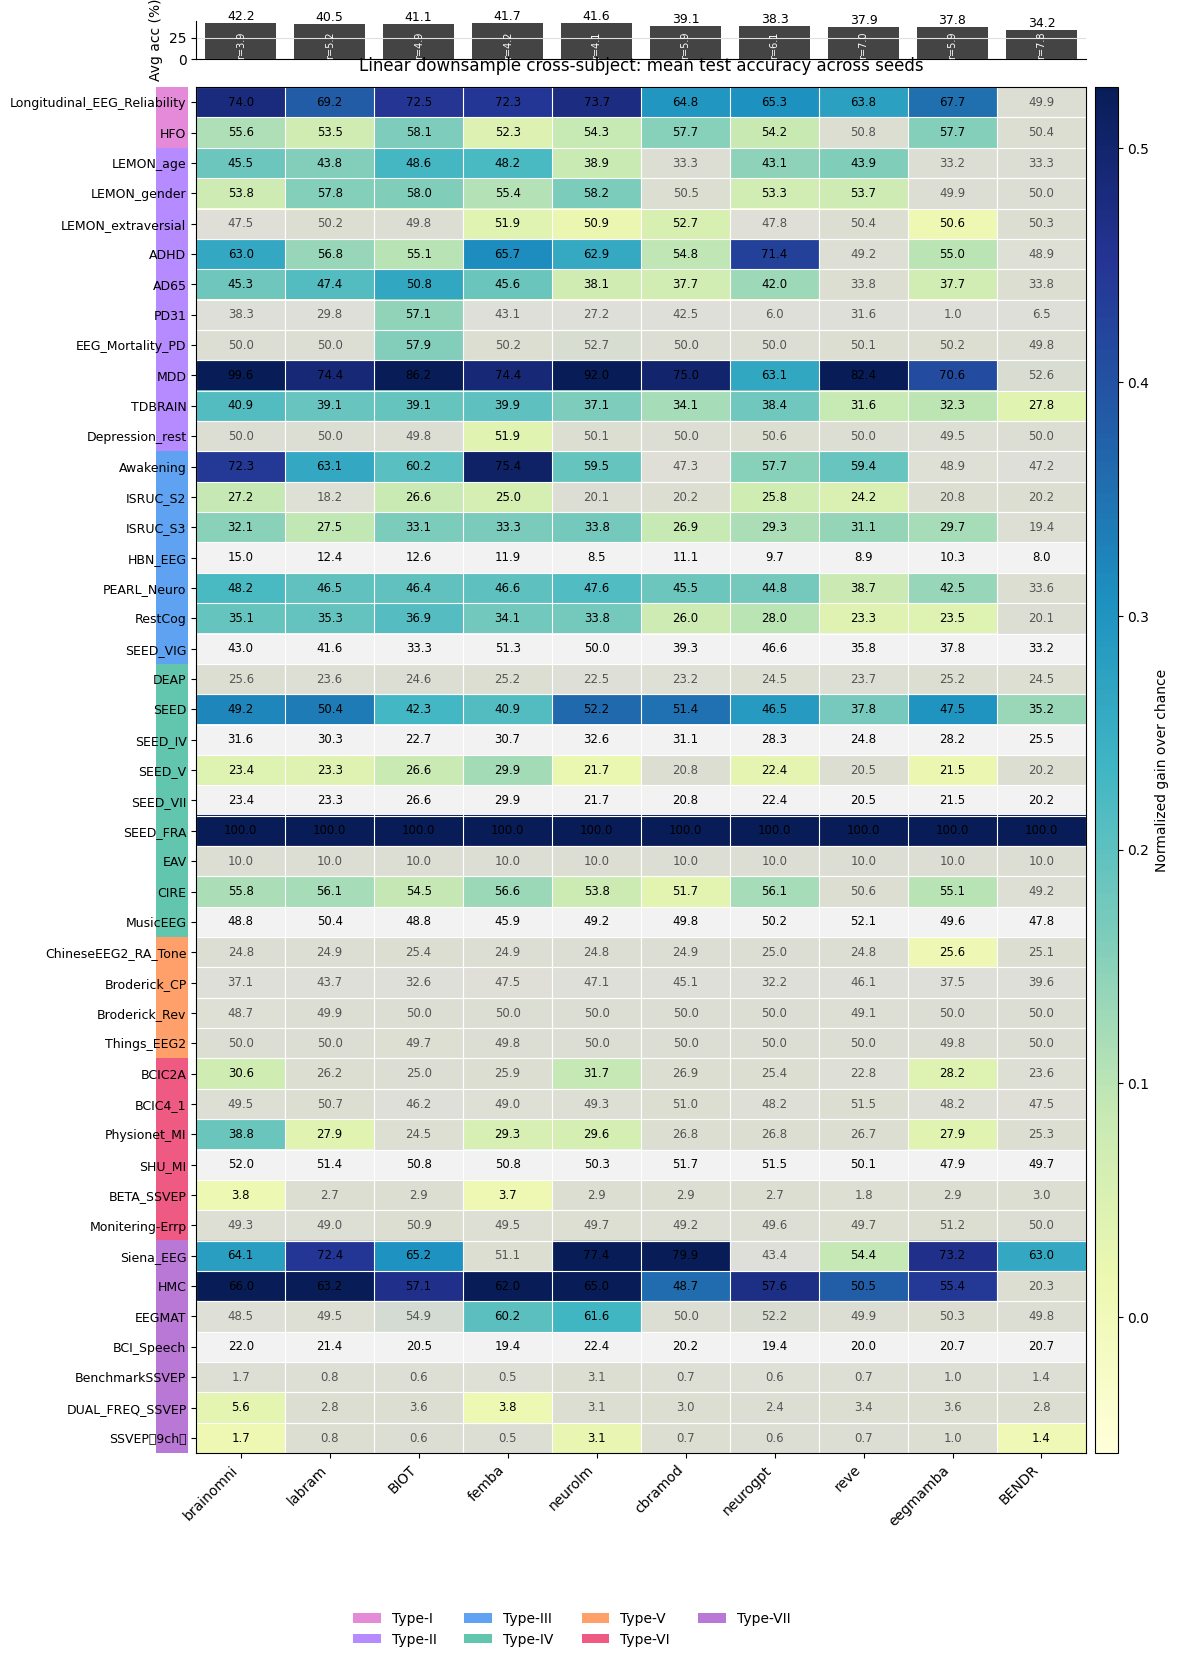

In [11]:
# -----------------------
# Heatmap visualization
# -----------------------
def format_cell(value):
    if pd.isna(value):
        return "×"
    return f"{value * 100:.1f}" if DISPLAY_AS_PERCENT else f"{value:.3f}"

n_rows, n_cols = acc_pivot.shape
fig_h = max(8, 0.34 * n_rows + 2.6)
fig_w = max(12, 0.85 * n_cols + 4.5)
fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=False)

# Layout: category strip, heatmap, colorbar, top bar.
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[1.25, n_rows],
    width_ratios=[0.35, n_cols, 0.25],
    hspace=0.04,
    wspace=0.03,
)
ax_top = fig.add_subplot(gs[0, 1])
ax_strip = fig.add_subplot(gs[1, 0])
ax = fig.add_subplot(gs[1, 1])
cax = fig.add_subplot(gs[1, 2])

plot_values = color_matrix.to_numpy(dtype=float)
masked = np.ma.masked_invalid(plot_values)

if COLOR_BY == "normalized_gain":
    vmin = np.nanpercentile(plot_values, 5) if np.isfinite(plot_values).any() else 0
    vmax = np.nanpercentile(plot_values, 95) if np.isfinite(plot_values).any() else 1
    vmin = min(vmin, 0)
    vmax = max(vmax, 0.05)
    cmap = mpl.cm.YlGnBu.copy()
else:
    vmin = np.nanmin(plot_values) if np.isfinite(plot_values).any() else 0
    vmax = np.nanmax(plot_values) if np.isfinite(plot_values).any() else 1
    cmap = mpl.cm.YlGnBu.copy()
cmap.set_bad("#F2F2F2")

im = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
cb = fig.colorbar(im, cax=cax)
cb.set_label(color_label, rotation=90)

# Grid lines
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels([m.upper() if m in {"biot", "bendr"} else m for m in MODEL_ORDER], rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(dataset_order, fontsize=9)
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_title("Linear downsample cross-subject: mean test accuracy across seeds", pad=12)

# Cell text and gray nonsignificant cells.
for i, dataset in enumerate(dataset_order):
    for j, model in enumerate(MODEL_ORDER):
        value = acc_pivot.loc[dataset, model]
        sig = sig_pivot.loc[dataset, model] if dataset in sig_pivot.index and model in sig_pivot.columns else np.nan
        if pd.isna(value):
            ax.text(j, i, "×", ha="center", va="center", color="#555555", fontsize=10)
            continue
        if sig is False or str(sig).lower() == "false":
            rect = mpl.patches.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor="#D9D9D9", edgecolor="white", linewidth=0.8, alpha=0.82)
            ax.add_patch(rect)
            color = "#555555"
        else:
            color = "black"
        ax.text(j, i, format_cell(value), ha="center", va="center", color=color, fontsize=8.5)

# Category strip
cat_values = [category_by_dataset.get(d, "") for d in dataset_order]
unique_cats = list(dict.fromkeys(cat_values))
cat_to_idx = {c: i for i, c in enumerate(unique_cats)}
strip_array = np.array([[cat_to_idx[c]] for c in cat_values])
strip_cmap = ListedColormap([CATEGORY_COLORS.get(c, "#BBBBBB") for c in unique_cats])
ax_strip.imshow(strip_array, aspect="auto", cmap=strip_cmap)
ax_strip.set_xticks([])
ax_strip.set_yticks(np.arange(n_rows))
ax_strip.set_yticklabels([])
ax_strip.tick_params(left=False)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

# Top bar: model mean accuracy, with avg rank labels as small secondary information.
bar_values = model_mean_acc.reindex(MODEL_ORDER).to_numpy(dtype=float)
ax_top.bar(np.arange(n_cols), bar_values * (100 if DISPLAY_AS_PERCENT else 1), color="#444444")
ax_top.set_xlim(-0.5, n_cols - 0.5)
ax_top.set_xticks([])
ax_top.set_ylabel("Avg acc" + (" (%)" if DISPLAY_AS_PERCENT else ""))
ax_top.grid(axis="y", color="#E0E0E0", linewidth=0.8)
for j, model in enumerate(MODEL_ORDER):
    y = bar_values[j] * (100 if DISPLAY_AS_PERCENT else 1)
    if np.isfinite(y):
        ax_top.text(j, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)
        ax_top.text(j, 0, f"r={model_avg_rank[model]:.1f}", ha="center", va="bottom", fontsize=7, color="white", rotation=90)
ax_top.spines[["top", "right"]].set_visible(False)

legend_handles = [Patch(facecolor=CATEGORY_COLORS.get(c, "#BBBBBB"), label=c) for c in unique_cats]
fig.legend(handles=legend_handles, loc="lower center", ncol=min(4, len(legend_handles)), frameon=False, bbox_to_anchor=(0.5, 0.005))

fig.subplots_adjust(left=0.18, right=0.92, top=0.92, bottom=0.12)
plt.show()

In [12]:
# -----------------------
# Tables for inspection inside the notebook only
# -----------------------
display_cols = [
    "dataset_display", "category", "model", "mean_accuracy", "std_accuracy", "n_seed",
    "missing_seeds", "chance", "n_test", "p_value", "test_method", "significant",
]
summary_df.sort_values(["dataset_display", "model"])[display_cols].head(100)

,dataset_display,category,model,mean_accuracy,std_accuracy,n_seed,missing_seeds,chance,n_test,p_value,test_method,significant
68,AD65,Type-II,bendr,0.338094,9.718104e-03,3,,0.333,715,3.919422e-01,binomial,False
60,AD65,Type-II,biot,0.508365,1.195470e-01,3,,0.333,715,4.991319e-22,binomial,True
62,AD65,Type-II,brainomni,0.452694,1.244370e-01,3,,0.333,715,1.762822e-11,binomial,True
66,AD65,Type-II,cbramod,0.376872,2.586045e-02,3,,0.333,715,8.348602e-03,binomial,True
65,AD65,Type-II,eegmamba,0.376677,6.125454e-02,3,,0.333,715,8.348602e-03,binomial,True
69,AD65,Type-II,femba,0.455766,1.097670e-01,3,,0.333,715,6.223138e-12,binomial,True
61,AD65,Type-II,labram,0.473991,1.149732e-01,3,,0.333,715,4.177419e-15,binomial,True
64,AD65,Type-II,neurogpt,0.419519,9.254870e-02,3,,0.333,715,8.387200e-07,binomial,True
63,AD65,Type-II,neurolm,0.380817,1.672338e-01,3,,0.333,715,4.310677e-03,binomial,True
67,AD65,Type-II,reve,0.337552,2.258035e-02,3,,0.333,715,4.226659e-01,binomial,False


In [13]:
# Datasets expected by the reference but not matched to any result directory.
unmatched = matched.loc[matched["result_dir"].isna(), ["category", "dataset_display", "linear_downsample_cross"]]
unmatched

,category,dataset_display,linear_downsample_cross
0,Type-I,EEG_IO,NaN
14,Type-II,TUEP,NaN
16,Type-III,ISRUC_S1,NaN
19,Type-III,SleepEDF_full,NaN
46,Type-VII,CHB_MIT,NaN
52,Type-VII,Workload,NaN
